In [3]:
import os, random
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
sns.set_style('darkgrid')
import torch
from torch import nn, optim
from torchtext import data
from torchtext import datasets
import torch.nn.functional as F
import spacy

SEED = 44
torch.manual_seed(SEED)

device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(device)

cpu



A module that was compiled using NumPy 1.x cannot be run in
NumPy 2.0.2 as it may crash. To support both 1.x and 2.x
versions of NumPy, modules must be compiled with NumPy 2.0.
Some module may need to rebuild instead e.g. with 'pybind11>=2.12'.

If you are a user of the module, the easiest solution will be to
downgrade to 'numpy<2' or try to upgrade the affected module.
We expect that some modules will need time to support NumPy 2.

Traceback (most recent call last):  File "<frozen runpy>", line 198, in _run_module_as_main
  File "<frozen runpy>", line 88, in _run_code
  File "/usr/local/lib/python3.11/dist-packages/colab_kernel_launcher.py", line 37, in <module>
    ColabKernelApp.launch_instance()
  File "/usr/local/lib/python3.11/dist-packages/traitlets/config/application.py", line 992, in launch_instance
    app.start()
  File "/usr/local/lib/python3.11/dist-packages/ipykernel/kernelapp.py", line 712, in start
    self.io_loop.start()
  File "/usr/local/lib/python3.11/dist-package

In [4]:
#!pip install torchtext==0.15.2
#!pip install torchtext==0.6.0
#!python -m spacy download en_core_web_sm

## IMDb Reviews


<img src="https://drive.google.com/uc?export=view&id=1I5dBhbKnPPq-m8CiwaKrvg6LGuT8bkTb" width="700">

Similar ao torchvision para imagens, o pacote torchtext facilita o trabalho com texto, oferecendo ferramentas aproveitáveis para outros dados sequenciais.

Um dos seus principais elementos é o `Field`, objeto que carrega informações de como os dados devem ser processados.

No nosso caso temos dois dados:
* Texto: Uma sequência de caracteres que será dividida em **tokens**. Armazenaremos também os tamanhos das frases pois mais a frente veremos como trabalhar com sequências de tamanhos variáveis

  * Ex: "Bom dia Brasil!" $\rightarrow$ `["bom", "dia", "brasil", "!"]`



* Label: Categorias descritas como "pos" e "neg". Essas serão transformadas para valores numéricos {neg: 0, pos: 1}





In [5]:
nlp = spacy.load("en_core_web_sm")
def tokenize_spacy(text):
    return [token.text for token in nlp(text)]
TEXT = data.Field(tokenize=tokenize_spacy, include_lengths=True)
LABEL = data.LabelField(dtype=torch.long)

train_data, test_data = datasets.IMDB.splits(TEXT, LABEL)
train_data, valid_data = train_data.split(random_state=random.seed(SEED))

TEXT.build_vocab(train_data, max_size=25000, vectors="glove.6B.100d", unk_init=torch.Tensor.normal_)
LABEL.build_vocab(train_data)

print(vars(train_data.examples[0]))

downloading aclImdb_v1.tar.gz


aclImdb_v1.tar.gz: 100%|██████████| 84.1M/84.1M [00:04<00:00, 21.0MB/s]
.vector_cache/glove.6B.zip: 862MB [02:39, 5.41MB/s]                           
100%|█████████▉| 399999/400000 [00:16<00:00, 24088.50it/s]


{'text': ['Horrendous', 'pillaging', 'of', 'a', 'classic.<br', '/><br', '/>It', 'was', "n't", 'written', 'convincingly', 'at', 'all', 'why', 'Mary', 'should', 'develop', 'such', 'sympathy', 'for', 'Bates', '.', 'He', 'may', 'be', 'more', 'stable', 'until', 'they', 'start', 'playing', 'pranks', 'with', 'him', ',', 'but', 'he', 'still', 'does', "n't", 'help', 'himself', 'at', 'all', 'with', 'his', 'actions', '.', '(', 'inviting', 'a', 'comparative', 'stranger', 'to', 'stay', 'alone', 'with', 'him', 'in', 'his', 'until', 'recently', 'disused', 'motel', ';', 'telling', 'the', 'attractive', 'young', 'girl', 'of', 'his', 'past', 'mental', 'issues', ';', 'lying', 'about', 'the', 'knives', ',', 'etc', '...', ')', 'This', ',', 'in', 'addition', 'to', 'her', 'previous', 'knowledge', 'should', 'have', 'kept', 'Mary', 'extremely', 'wary', 'of', 'him', ',', 'but', 'this', 'somehow', 'does', "n't", 'happen', 'just', 'so', 'they', 'can', 'play', 'the', "'", 'mistaken', '-', 'identity', '-', 'murder',

In [6]:
for amostra in valid_data:
  print(vars(amostra), '\n')
  print(amostra.text, '\n')
  print(amostra.label)
  break

{'text': ['This', 'movie', 'was', 'absolutely', 'wonderful', '.', 'The', 'pre', '-', 'partition', 'time', 'and', 'culture', 'has', 'been', 'recreated', 'beautifully', '.', 'Urmila', 'has', 'given', 'yet', 'another', 'brilliant', 'performance', '.', 'What', 'I', 'truly', 'admire', 'about', 'this', 'movie', 'is', 'that', 'it', 'does', "n't", 'resort', 'to', 'Pakistan', '-', 'bashing', 'that', 'is', 'running', 'rampant', 'in', 'movies', 'like', 'Gadar', 'and', 'LOC', '.', 'With', 'the', 'partition', 'as', 'a', 'backdrop', ',', 'the', 'movie', 'does', 'not', 'divert', 'to', 'political', 'issues', 'or', 'focus', 'on', 'violence', 'or', 'what', 'is', 'right', 'and', 'wrong', '.', 'The', 'movie', 'always', 'centers', 'around', 'the', 'tragic', 'story', 'of', 'Urmila', "'s", 'life', '.', 'Her', 'fragile', 'relationship', 'with', 'Manoj', 'Bajpai', 'has', 'been', 'depicted', 'excellently', '.', 'The', 'movie', 'actually', 'shows', 'how', 'the', 'people', ',', 'both', 'Hindus', 'and', 'Muslims',

In [7]:
print('Tamanho do vocabulario', len(TEXT.vocab),'\n')
print(TEXT.vocab.itos[:10],'\n', LABEL.vocab.stoi, '\n')

Tamanho do vocabulario 25002 

['<unk>', '<pad>', 'the', ',', '.', 'a', 'and', 'of', 'to', 'is'] 
 defaultdict(None, {'neg': 0, 'pos': 1}) 



In [8]:
TEXT.vocab.freqs.most_common(20), TEXT.vocab.vectors[0].shape

([('the', 201234),
  (',', 192186),
  ('.', 165311),
  ('a', 109261),
  ('and', 108798),
  ('of', 100337),
  ('to', 93353),
  ('is', 75921),
  ('in', 61291),
  ('I', 54100),
  ('it', 53584),
  ('that', 49433),
  ('"', 44345),
  ("'s", 43525),
  ('this', 42264),
  ('-', 37310),
  ('/><br', 35678),
  ('was', 34944),
  ('as', 30312),
  ('with', 29807)],
 torch.Size([100]))

In [9]:
LABEL.vocab.freqs.most_common(20)

[('neg', 8797), ('pos', 8703)]

### Embedding Layer

Documentação Pytorch: https://pytorch.org/docs/stable/nn.html#torch.nn.Embedding

Camadas de embedding são treinadas para mapear um ínidice numérico para um vetor denso de maior carga semântica.

Acabamos de ver a representação de palavras como ínidices de um vocabulário fixo. Apesar do índice informar a qual palavra estamos nos referindo, ele não incorpora nenhuma informação semântica sobre a palavra. O treinamento de embeddings para dados textuais tem como objetivo projetar esses índices em um espaço onde palavras semanticamente similares estejam próximas.

![](https://drive.google.com/uc?export=view&id=1pliMSOcjjOZAiR26ycowSeUJsj5cy9W_)

No Pytorch, a instância dessa classe recebe como parâmetro ```(vocab_size, embedding_size, padding_idx)```
* ```vocab_size```: Tamanho do vocabulário. Note que **não** se trata da dimensionalidade da entrada.
* ```embedding_size```: Dimensionalidade da dimensão latente. Caso haja o aproveitamento de embeddings pré treinadas deve-se definir a dimensionalidade da camada em função dos pesos que serão importados (ex: glove.6b.100d, ```embedding_size=100```).


Já pedimos esses vectores pré-treinados do GloVe

In [10]:
class RNN(nn.Module):
  def __init__(self, vocab_size, embed_dim, embed_vectors, ind_unk, ind_pad):
    super(RNN, self).__init__()

    self.embedding = nn.Embedding(vocab_size, embed_dim)
    self.embedding.weight.data.copy_(embed_vectors)
    self.embedding.weight.data[ind_unk] = torch.zeros(embed_dim)
    self.embedding.weight.data[ind_pad] = torch.zeros(embed_dim)

  def forward(self, x):
    # S x B x 25002
    embed = self.embedding(x)
    # S x B x 100
    return embed


vocab_size = len(TEXT.vocab)
embed_dim = TEXT.vocab.vectors[0].shape[0]
embed_vectors = TEXT.vocab.vectors
ind_pad = TEXT.vocab.stoi[TEXT.pad_token]
ind_unk = TEXT.vocab.stoi[TEXT.unk_token]
model = RNN(vocab_size, embed_dim, embed_vectors,
            ind_unk, ind_pad)

print(model)

RNN(
  (embedding): Embedding(25002, 100)
)


## BucketIterator
Essa classe do Torchtext funciona de forma análoga ao DataLoader do PyTorch,  porém leva em consideração a construção de **batches com sequências de comprimento variável**. Internamente ele agrega sequências de comprimento similar, **minimizando a quantidade de padding necessária**.

Além disso, os dados já saem preparados para serem empacotados pela função ```pack_padded_sequence``` ordenados por comprimento de sequência e informando o comprimento real de cada amostra (sem padding).

> Exemplo: Para compor um tensor com 5 amostras de frases com tamanhos variáveis, a segunda dimensão é definida pela frase de maior comprimento. Amostras menores são complementadas com tokens nulos (`<pad>`).

<img src="https://drive.google.com/uc?export=view&id=1uOf8NpztcNyV0Dq9Ch5oJoKuPnwPptqK" width="450">


Documentação: https://torchtext.readthedocs.io/en/latest/data.html?highlight=BucketIterator#torchtext.data.BucketIterator


In [11]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

train_iterator, test_iterator = data.BucketIterator.splits(
    (train_data, test_data),
    batch_size=64,
    sort_within_batch=True,
    device=device
)

In [12]:
for amostra in test_iterator:
  batch, tamanhos = amostra.text
  rotulo = amostra.label

  # S x B x N
  print('Texto: ', batch.shape, '\n\nTamanho: ', tamanhos, '\n\nLabel: ', rotulo.shape)
  break

Texto:  torch.Size([36, 64]) 

Tamanho:  tensor([36, 36, 36, 36, 36, 36, 36, 36, 35, 35, 35, 35, 35, 35, 34, 34, 34, 34,
        33, 33, 33, 33, 32, 32, 32, 32, 32, 32, 32, 31, 31, 31, 31, 30, 30, 29,
        29, 29, 29, 28, 28, 28, 28, 27, 27, 27, 27, 26, 26, 23, 23, 23, 22, 22,
        22, 20, 16, 16, 13, 12, 12, 11,  8,  5]) 

Label:  torch.Size([64])


## Padding and Packing (Preenchendo e empacotando)

O pacote de funções de rnn, ```nn.utils.rnn```, oferece meios de processar batches contendo sequências de tamanho variável. Isso é realizado através do **padding** da sequência (ex: preenchimento com zeros),  de modo que elas aparentem ter igual comprimento, porém internamente as posições preenchidas não são processadas pela RNN.

*  Vamos lembrar do nosso batch de frases com tamanhos variáveis:

<img src="https://drive.google.com/uc?export=view&id=1uOf8NpztcNyV0Dq9Ch5oJoKuPnwPptqK" width="450">


*  O empacotamento precisa receber os dados em ordem decrescente de comprimento, e internamente são criados "mini batches" com o seu batch. Dessa forma, apenas os timesteps que contém informação relevante sobre o dado são apresentadas à rede. Igualmente, somente esses timesteps impactam no backpropagation.

<img src="https://drive.google.com/uc?export=view&id=1ySh4IdDO4Iw3G8p2iSdo62MW_z4kR5fd" width="450">


Para isso basta realizar o padding das suas sequências, **preservando os comprimetos originais** em outra variável. Na prática, o forward recebe mais um parâmetro, aqui chamamos de **```tamanhos```**, referente ao comprimento de cada amostra dentro do batch **```X```**, ordenado de forma descrescente.

Tendo em mãos (1) o batch de sequências preenchidas e ordenadas, e (2) o comprimento original de cada amostra, basta realizar as seguintes operações no forward da rede:

```python
## Empacote a sequência antes de alimentar a unidade recorrente
packed_input = nn.utils.rnn.pack_padded_sequence(X, tamanhos)

## Forward recorrente
packed_output, hidden = self.rnn(packed_input, hidden )

## Desempacote a sequência para continuar o fluxo na rede.
output, output_lengths = nn.utils.rnn.pad_packed_sequence(packed_output)
```

In [13]:
 class RNN(nn.Module):

  def __init__(self, tam_vocab, tam_embedding, embed_vectors,
               ind_unk, ind_pad, hidden_size):
    super(RNN, self).__init__()

    # Inicializaremos a camada de embedding
    self.embedding = nn.Embedding(tam_vocab, tam_embedding)
    self.embedding.weight.data.copy_(embed_vectors)
    self.embedding.weight.data[ind_unk] = torch.zeros(tam_embedding)
    self.embedding.weight.data[ind_pad] = torch.zeros(tam_embedding)
    #######################################

    # Camada recorrente
    self.hidden_size = hidden_size
    self.rnn = nn.GRU(tam_embedding, hidden_size)


  def forward(self, X, tamanhos):
    print('X:', X.size(), '\n')
    # S x B x 25002
    print('tamanhos', tamanhos, '\n')
    vectors = self.embedding(X)
    # S x B x 100
    print('Vectors:', vectors.size(), '\n')

    hidden = torch.randn(1, X.size(1), self.hidden_size).to(device)
    print("Hidden: ", hidden.size())

    ## Empacote a sequência antes de alimentar a unidade recorrente
    packed_input = nn.utils.rnn.pack_padded_sequence(vectors, tamanhos)
    print('Packed input:', packed_input.batch_sizes, '\n')

    ## Forward recorrente
    packed_output, hidden = self.rnn(packed_input, hidden )
    print('Packed output:', packed_output.batch_sizes, '\n')

    ## Desempacote a sequência para continuar o fluxo na rede.
    output, output_lengths = nn.utils.rnn.pad_packed_sequence(packed_output)
    print('output:', output.size(), '\n')

    return output


tam_vocab = len(TEXT.vocab)
tam_embedding = TEXT.vocab.vectors[0].shape[0]
embed_vectors = TEXT.vocab.vectors
ind_pad = TEXT.vocab.stoi[TEXT.pad_token]
ind_unk = TEXT.vocab.stoi[TEXT.unk_token]

hidden_size = 256

model = RNN(tam_vocab, tam_embedding, embed_vectors,
               ind_unk, ind_pad, hidden_size).to(device)

print(model)

RNN(
  (embedding): Embedding(25002, 100)
  (rnn): GRU(100, 256)
)


In [14]:
for sample in test_iterator:
  texto, tamanhos = sample.text
  label = sample.label

  saida = model(texto, tamanhos)
  break

X: torch.Size([36, 64]) 

tamanhos tensor([36, 36, 36, 36, 36, 36, 36, 36, 35, 35, 35, 35, 35, 35, 34, 34, 34, 34,
        33, 33, 33, 33, 32, 32, 32, 32, 32, 32, 32, 31, 31, 31, 31, 30, 30, 29,
        29, 29, 29, 28, 28, 28, 28, 27, 27, 27, 27, 26, 26, 23, 23, 23, 22, 22,
        22, 20, 16, 16, 13, 12, 12, 11,  8,  5]) 

Vectors: torch.Size([36, 64, 100]) 

Hidden:  torch.Size([1, 64, 256])
Packed input: tensor([64, 64, 64, 64, 64, 63, 63, 63, 62, 62, 62, 61, 59, 58, 58, 58, 56, 56,
        56, 56, 55, 55, 52, 49, 49, 49, 47, 43, 39, 35, 33, 29, 22, 18, 14,  8]) 

Packed output: tensor([64, 64, 64, 64, 64, 63, 63, 63, 62, 62, 62, 61, 59, 58, 58, 58, 56, 56,
        56, 56, 55, 55, 52, 49, 49, 49, 47, 43, 39, 35, 33, 29, 22, 18, 14,  8]) 

output: torch.Size([36, 64, 256]) 



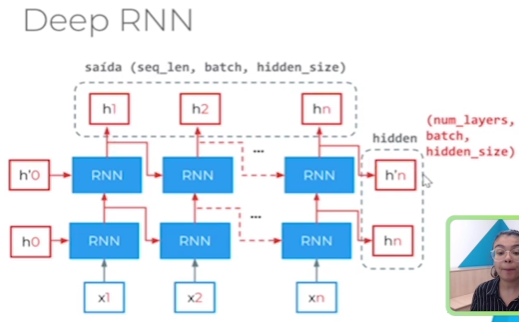

In [15]:
 class RNN(nn.Module):

  def __init__(self, tam_vocab, tam_embedding, embed_vectors,
               ind_unk, ind_pad, hidden_size, output_size):
    super(RNN, self).__init__()

    # Inicializaremos a camada de embedding
    self.embedding = nn.Embedding(tam_vocab, tam_embedding)
    self.embedding.weight.data.copy_(embed_vectors)
    self.embedding.weight.data[ind_unk] = torch.zeros(tam_embedding)
    self.embedding.weight.data[ind_pad] = torch.zeros(tam_embedding)
    #######################################

    # Camada recorrente
    self.hidden_size = hidden_size
    self.rnn = nn.GRU(tam_embedding, hidden_size)
    self.linear = nn.Linear(hidden_size, output_size)


  def forward(self, X, tamanhos):

    # S x B x 25002

    vectors = self.embedding(X)
    # S x B x 100


    hidden = torch.randn(1, X.size(1), self.hidden_size).to(device)


    ## Empacote a sequência antes de alimentar a unidade recorrente
    packed_input = nn.utils.rnn.pack_padded_sequence(vectors, tamanhos)


    ## Forward recorrente
    packed_output, hidden = self.rnn(packed_input, hidden)


    ## Desempacote a sequência para continuar o fluxo na rede.
    output, output_lengths = nn.utils.rnn.pad_packed_sequence(packed_output)
    # S x B x F / hidden = 1 x B x F
    output = self.linear(hidden.squeeze()) # B x F -> B x output

    print(output.size())
    return output


tam_vocab = len(TEXT.vocab)
tam_embedding = TEXT.vocab.vectors[0].shape[0]
embed_vectors = TEXT.vocab.vectors
ind_pad = TEXT.vocab.stoi[TEXT.pad_token]
ind_unk = TEXT.vocab.stoi[TEXT.unk_token]

hidden_size = 256
output_size = 2

model = RNN(tam_vocab, tam_embedding, embed_vectors,
               ind_unk, ind_pad, hidden_size, output_size).to(device)

print(model)

RNN(
  (embedding): Embedding(25002, 100)
  (rnn): GRU(100, 256)
  (linear): Linear(in_features=256, out_features=2, bias=True)
)


In [16]:
for sample in test_iterator:
  texto, tamanhos = sample.text
  label = sample.label

  saida = model(texto, tamanhos.cpu())
  break

torch.Size([64, 2])


In [17]:
criterio = nn.CrossEntropyLoss().to(device)
optimizer = optim.Adam(model.parameters(), lr=1e-4, weight_decay=5e-5)

In [18]:
def forward(iterator, num_samples, etapa):
  if etapa == 'Treino': model.train()
  else: model.eval()

  acuracia = 0.
  loss_epoca = []
  for k, sample in enumerate(iterator):

    texto, tamanhos = sample.text
    rotulo = sample.label

    saida = model(texto, tamanhos.cpu())

    loss = criterio(saida, rotulo)
    loss_epoca.append(loss.item())

    _, pred = torch.max(saida, axis=-1)
    acuracia += (pred.cpu().data == rotulo.cpu().data).sum()

    if etapa == 'Treino':
      # Otimização
      optimizer.zero_grad()
      loss.backward()
      optimizer.step()

  loss_epoca = np.asarray(loss_epoca).ravel()
  acuracia   = acuracia/float(num_samples)
  print('\n','*'*15 + etapa + '*'*15 )
  print('Epoca: {:}, Loss: {:.4f} +/- {:.4f}, Acurácia: {:.4f}'.format(epoca, loss_epoca.mean(),
                                                                        loss_epoca.std(),
                                                                        acuracia
                                                                       ))
  return loss_epoca.mean(), acuracia

In [ ]:
loss_treino, loss_test = [], []
acc_treino, acc_test = [], []

for epoca in range(8):
  loss, acuracia = forward(train_iterator, len(train_data), 'Treino')
  loss_treino.append(loss)
  acc_treino.append(acuracia)

  loss, acuracia = forward(test_iterator, len(test_data), 'Teste')
  loss_test.append(loss)
  acc_test.append(acuracia)


torch.Size([64, 2])


In [ ]:
import spacy
nlp = spacy.load('en')

def predict_sentiment(sentence):
    model.eval()
    tokenized = [str(tok) for tok in nlp.tokenizer(sentence)]
    print(tokenized)

    indexed = [TEXT.vocab.stoi[t] for t in tokenized]
    length = [len(indexed)]
    print(indexed)

    tensor = torch.LongTensor(indexed).to(device)
    tensor = tensor.unsqueeze(1)
    length_tensor = torch.LongTensor(length)

    prediction = model(tensor, length_tensor)

    return F.softmax(prediction, dim=-1).cpu().data

In [ ]:
np.random.seed(42)
for i in range(5):
  idx = np.random.choice(len(test_data))
  text = test_data[idx].text
  pred = predict_sentiment(' '.join(text) )

  plt.bar(0, pred[0], color='darkred', label='Negativo', width=0.5)
  plt.bar(1, pred[1], color='dodgerblue', label='Positivo', width=0.5)
  plt.title(str(test_data[idx].label))
  plt.legend()
  plt.show()

* Análise de sentimentos

Na nossa segunda prática implementamos uma solução para o problema de análise de sentimentos no dataset IMDB de reviews de filmes.

* Torchtext

Você conheceu um dos muitos pacotes construídos para o PyTorch, oferecendo poder adicional ao framework. O Torchtext provê uma série de ferramentas para carregamento e manipulação de texto.

* Camada de Embedding

Aprendemos um pouco sobre a representação de palavras em um espaço semântico que codifica informação de contexto das palavras de um vocabulário. Utilizamos o Global Vectors, um modelo pré-treinado de representação.

* BucketIterator

Também sobre o Torchtext, conhecemos uma das maneiras de preparar os dados para alimentar o empacotamento de sequências do PyTorch.

* Lidando com sequências de comprimento variável

Você conheceu o artifício de empacotamento de sequências do PyTorch, que permite alimentar um batch de sequências de comprimento variável para a rede neural, permitindo um treinamento eficiente do modelo.